# RL Agent Comparison: Tabular Q, DQN, Double DQN, Dueling DQN

This notebook compares four reinforcement learning agents for traffic signal control:

1. **Tabular Q-Learning** — Classic value-based method for small state spaces
2. **DQN** — Deep Q-Network with replay buffer and target network
3. **Double DQN** — Reduces Q-value overestimation using separate action selection
4. **Dueling DQN** — Splits network into value and advantage streams

**Flow:**
1. Import and setup
2. Display agent comparison matrix
3. Run benchmark on synthetic environment
4. Visualize results with plots and tables
5. Recommendations based on performance

## Section 1: Imports and Setup

In [17]:
from __future__ import annotations

import json
import sys
import time
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, JSON, Markdown, display

def _find_repo_root(start: Path) -> Path:
    """Find the repository root by looking for pyproject.toml."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError(f"Could not locate repo root from {start}")

REPO_ROOT = _find_repo_root(Path.cwd()).resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from traffic_rl.agents.factory import build_agent
from traffic_rl.config import AppConfig

print(f"Repository root: {REPO_ROOT}")
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Repository root: /home/hd/projects/ML_project/traffic-rl
Python version: 3.10.15
NumPy version: 2.2.6
Pandas version: 2.3.3


## Section 2: Agent Comparison Matrix

Below is a summary of the four agents and their key characteristics.

In [18]:
# Agent comparison data
agent_comparison = {
    "Tabular Q-Learning": {
        "Type": "Value-based, Tabular",
        "State Space": "Small discrete",
        "Network": "None (lookup table)",
        "Complexity": "Very Low",
        "Convergence": "Guaranteed (tabular)",
        "Best For": "Baseline, small problems",
        "Key Innovation": "N/A"
    },
    "DQN": {
        "Type": "Value-based, Deep",
        "State Space": "Large continuous",
        "Network": "2-layer MLP",
        "Complexity": "Medium",
        "Convergence": "Replay buffer + target net",
        "Best For": "Quick deep RL baseline",
        "Key Innovation": "Experience replay, target network"
    },
    "Double DQN": {
        "Type": "Value-based, Deep",
        "State Space": "Large continuous",
        "Network": "2-layer MLP",
        "Complexity": "Medium",
        "Convergence": "Decoupled action selection",
        "Best For": "Production (stable learning)",
        "Key Innovation": "Online net → actions, target net → evaluation"
    },
    "Dueling DQN": {
        "Type": "Value-based, Deep",
        "State Space": "Large continuous",
        "Network": "Dueling (V + A streams)",
        "Complexity": "Medium-High",
        "Convergence": "Separate learning paths",
        "Best For": "Complex state spaces",
        "Key Innovation": "Q(s,a) = V(s) + A(s,a) - mean(A)"
    }
}

# Convert to DataFrame for display
comparison_df = pd.DataFrame(agent_comparison).T
print(comparison_df.to_string())
print()
display(HTML(comparison_df.to_html(classes='table table-striped table-bordered')))

                                    Type       State Space                  Network   Complexity                 Convergence                      Best For                                 Key Innovation
Tabular Q-Learning  Value-based, Tabular    Small discrete      None (lookup table)     Very Low        Guaranteed (tabular)      Baseline, small problems                                            N/A
DQN                    Value-based, Deep  Large continuous              2-layer MLP       Medium  Replay buffer + target net        Quick deep RL baseline              Experience replay, target network
Double DQN             Value-based, Deep  Large continuous              2-layer MLP       Medium  Decoupled action selection  Production (stable learning)  Online net → actions, target net → evaluation
Dueling DQN            Value-based, Deep  Large continuous  Dueling (V + A streams)  Medium-High     Separate learning paths          Complex state spaces               Q(s,a) = V(s) + A(s,a) 

,Type,State Space,Network,Complexity,Convergence,Best For,Key Innovation
Tabular Q-Learning,"Value-based, Tabular",Small discrete,None (lookup table),Very Low,Guaranteed (tabular),"Baseline, small problems",N/A
DQN,"Value-based, Deep",Large continuous,2-layer MLP,Medium,Replay buffer + target net,Quick deep RL baseline,"Experience replay, target network"
Double DQN,"Value-based, Deep",Large continuous,2-layer MLP,Medium,Decoupled action selection,Production (stable learning),"Online net → actions, target net → evaluation"
Dueling DQN,"Value-based, Deep",Large continuous,Dueling (V + A streams),Medium-High,Separate learning paths,Complex state spaces,"Q(s,a) = V(s) + A(s,a) - mean(A)"


## Section 3: Configuration and Benchmark Setup

Define hyperparameters and create agent configurations.

## Section 3b: Load Real PEMS Dataset

Load actual traffic flow data from the PEMS04 dataset for realistic benchmarking.

In [19]:
# Load PEMS04 dataset
PEMS_NPZ_PATH = REPO_ROOT / "Pems_Dataset" / "PEMS04" / "PEMS04.npz"

if PEMS_NPZ_PATH.exists():
    pems_data = np.load(PEMS_NPZ_PATH)
    pems_tensor = pems_data["data"]  # Shape: (timesteps, num_sensors, num_features)
    print(f"✓ PEMS04 dataset loaded")
    print(f"  Shape: {pems_tensor.shape} (timesteps, sensors, features)")
    print(f"  Data type: {pems_tensor.dtype}")
    print(f"  Size: {pems_tensor.nbytes / (1024**2):.1f} MB")
    
    # Extract features for benchmark
    PEMS_TIMESTEPS, PEMS_NUM_SENSORS, PEMS_NUM_FEATURES = pems_tensor.shape
    print(f"  Timesteps: {PEMS_TIMESTEPS}, Sensors: {PEMS_NUM_SENSORS}, Features: {PEMS_NUM_FEATURES}")
else:
    print(f"✗ PEMS04 dataset not found at {PEMS_NPZ_PATH}")
    pems_tensor = None

✓ PEMS04 dataset loaded
  Shape: (16992, 307, 3) (timesteps, sensors, features)
  Data type: float64
  Size: 119.4 MB
  Timesteps: 16992, Sensors: 307, Features: 3


In [20]:
# Shared hyperparameters for all deep agents
SHARED_HYPERPARAMS = {
    "gamma": 0.99,
    "learning_rate": 0.001,
    "epsilon_start": 1.0,
    "epsilon_end": 0.01,
    "epsilon_decay": 0.995,
    "hidden_dim": 64,
    "batch_size": 32,
    "replay_capacity": 10000,
    "learning_starts": 500,
    "target_update_interval": 500,
    "train_frequency": 4,
    "seed": 42,
}

# Benchmark settings (larger for real PEMS data)
BENCHMARK_CONFIG = {
    "num_episodes": 20,  # Increased for better statistical significance
    "steps_per_episode": 2000,  # Longer episodes for real data
    "action_size": 4,
}

display(Markdown("### Hyperparameters"))
display(JSON(SHARED_HYPERPARAMS, expanded=False))

print()
display(Markdown("### Benchmark Settings"))
display(JSON(BENCHMARK_CONFIG, expanded=False))

### Hyperparameters

<IPython.core.display.JSON object>

### Benchmark Settings

<IPython.core.display.JSON object>

## Section 4: Synthetic Environment and Agent Evaluation

Create a simple synthetic environment to evaluate agent learning capability.

In [ ]:
def create_agent_config(agent_type: str) -> AppConfig:
    """Create AppConfig for a specific agent type."""
    cfg = AppConfig()
    cfg.training.agent_type = agent_type
    cfg.training.gamma = SHARED_HYPERPARAMS["gamma"]
    cfg.training.learning_rate = SHARED_HYPERPARAMS["learning_rate"]
    cfg.training.epsilon_start = SHARED_HYPERPARAMS["epsilon_start"]
    cfg.training.epsilon_end = SHARED_HYPERPARAMS["epsilon_end"]
    cfg.training.epsilon_decay = SHARED_HYPERPARAMS["epsilon_decay"]
    cfg.training.hidden_dim = SHARED_HYPERPARAMS["hidden_dim"]
    cfg.training.batch_size = SHARED_HYPERPARAMS["batch_size"]
    cfg.training.replay_capacity = SHARED_HYPERPARAMS["replay_capacity"]
    cfg.training.learning_starts = SHARED_HYPERPARAMS["learning_starts"]
    cfg.training.target_update_interval = SHARED_HYPERPARAMS["target_update_interval"]
    cfg.training.train_frequency = SHARED_HYPERPARAMS["train_frequency"]
    cfg.seed = SHARED_HYPERPARAMS["seed"]
    return cfg

def synthetic_environment_step(agent, state: np.ndarray, step: int, action: int) -> tuple:
    """Simple synthetic environment for agent testing.
    
    Evaluates agent's ability to learn optimal policy. Reward is ACTION-DEPENDENT.
    """
    # Target is a sinusoidal signal
    target = np.sin(step / 50.0) * 5
    error = np.linalg.norm(state - target)
    
    # Base reward for state fitness
    base_reward = 1.0 - (error / 10.0)
    
    # ACTION-DEPENDENT bonus: different actions get different rewards based on target
    # This forces agents to learn which action is best for each state
    action_bonus = 0.0
    target_action = int((target + 5) / 2.5) % 4  # Map target to optimal action
    if action == target_action:
        action_bonus = 0.5  # +0.5 bonus for correct action
    else:
        action_bonus = -0.2  # -0.2 penalty for wrong action
    
    reward = base_reward + action_bonus
    
    # Next state dynamics with noise
    next_state = 0.9 * state + 0.1 * np.random.randn(10).astype(np.float32)
    next_state = np.clip(next_state, -5, 5).astype(np.float32)
    
    done = step >= BENCHMARK_CONFIG["steps_per_episode"] - 1
    
    return next_state, reward, done

def pems_environment_step(agent, pems_data: np.ndarray, timestep_idx: int, sensor_idx: int, action: int) -> tuple:
    """PEMS-based environment using real traffic flow data.
    
    State: normalized flow rates for all sensors.
    Action: 0-3 represents different signal timings/control strategies.
    Reward: ACTION-DEPENDENT based on congestion reduction.
    """
    # Extract state: flow rates from all sensors at current timestep
    current_state = pems_data[timestep_idx, :, 0].astype(np.float32)  # Feature 0 = flow
    current_state = np.clip(current_state / (current_state.max() + 1e-6), 0, 1)  # Normalize
    
    # Base reward for congestion level
    flow_value = pems_data[timestep_idx, sensor_idx, 0]
    max_flow = pems_data[:, sensor_idx, 0].max()
    congestion = flow_value / (max_flow + 1e-6)
    base_reward = 1.0 - congestion
    
    # ACTION-DEPENDENT component: simulate effect of signal control
    # High congestion → actions 0,1 are better (longer green for main road)
    # Low congestion → actions 2,3 are better (alternate signals)
    action_reward = 0.0
    if congestion > 0.6:  # High congestion
        if action in [0, 1]:
            action_reward = 0.3  # Bonus for main road priority
        else:
            action_reward = -0.1
    else:  # Low congestion
        if action in [2, 3]:
            action_reward = 0.3  # Bonus for alternating signals
        else:
            action_reward = -0.1
    
    reward = base_reward + action_reward
    
    # Next state (same normalization)
    next_timestep = min(timestep_idx + 1, pems_data.shape[0] - 1)
    next_state = pems_data[next_timestep, :, 0].astype(np.float32)
    next_state = np.clip(next_state / (next_state.max() + 1e-6), 0, 1)
    
    done = next_timestep >= pems_data.shape[0] - 1
    
    return next_state, float(reward), done

print("Environment functions defined with ACTION-DEPENDENT rewards.")
print(f"✓ Synthetic environment: Agents learn to select correct action for target")
print(f"✓ PEMS environment: Agents learn signal control strategy based on congestion" if pems_tensor is not None else "✗ PEMS environment (data not loaded)")
print("\n→ Different agents will now show different learning capabilities!")

Environment functions defined.
✓ Synthetic environment: 10-dim state, sinusoidal target
✓ PEMS environment: 307-dim state from real traffic data


## Section 5: Run Benchmark Simulation

Train each of the four agents and measure performance metrics.

## Section 4b: Load Real PEMS Dataset

Load actual traffic flow data from the PEMS04 dataset for realistic benchmarking.

In [22]:
# Load PEMS04 dataset
PEMS_NPZ_PATH = REPO_ROOT / "Pems_Dataset" / "PEMS04" / "PEMS04.npz"

if PEMS_NPZ_PATH.exists():
    pems_data = np.load(PEMS_NPZ_PATH)
    pems_tensor = pems_data["data"]  # Shape: (timesteps, num_sensors, num_features)
    print(f"✓ PEMS04 dataset loaded")
    print(f"  Shape: {pems_tensor.shape} (timesteps, sensors, features)")
    print(f"  Data type: {pems_tensor.dtype}")
    print(f"  Size: {pems_tensor.nbytes / (1024**2):.1f} MB")
    
    # Extract features for benchmark
    PEMS_TIMESTEPS, PEMS_NUM_SENSORS, PEMS_NUM_FEATURES = pems_tensor.shape
    print(f"  Timesteps: {PEMS_TIMESTEPS}, Sensors: {PEMS_NUM_SENSORS}, Features: {PEMS_NUM_FEATURES}")
else:
    print(f"✗ PEMS04 dataset not found at {PEMS_NPZ_PATH}")
    pems_tensor = None

✓ PEMS04 dataset loaded
  Shape: (16992, 307, 3) (timesteps, sensors, features)
  Data type: float64
  Size: 119.4 MB
  Timesteps: 16992, Sensors: 307, Features: 3


In [ ]:
def benchmark_agent(agent_type: str, use_pems: bool = False) -> dict:
    """Run benchmark for a single agent type.
    
    Args:
        agent_type: Type of agent to benchmark
        use_pems: If True, use PEMS real data; otherwise use synthetic environment
    """
    cfg = create_agent_config(agent_type)
    
    if use_pems and pems_tensor is not None:
        action_size = 4
        state_size = PEMS_NUM_SENSORS
    else:
        action_size = BENCHMARK_CONFIG["action_size"]
        state_size = 10
    
    agent = build_agent(cfg, action_size=action_size)
    
    total_reward = 0.0
    episode_rewards = []
    
    start_time = time.time()
    
    num_episodes = BENCHMARK_CONFIG["num_episodes"]
    steps_per_episode = BENCHMARK_CONFIG["steps_per_episode"]
    
    for episode in range(num_episodes):
        if use_pems and pems_tensor is not None:
            # Use PEMS data: each "episode" is a continuous segment
            start_idx = (episode * steps_per_episode) % (PEMS_TIMESTEPS - steps_per_episode)
            sensor_idx = episode % PEMS_NUM_SENSORS
        else:
            # Synthetic: random initial state
            start_idx = 0
            sensor_idx = 0
        
        state = np.random.randn(state_size).astype(np.float32) if not use_pems else pems_tensor[start_idx, :, 0].astype(np.float32)
        if use_pems and pems_tensor is not None:
            state = np.clip(state / (state.max() + 1e-6), 0, 1)
        
        episode_reward = 0.0
        
        for step in range(steps_per_episode):
            # Agent selects action based on current state
            action = agent.act(state, train=True)
            
            # Environment step: action-dependent reward
            if use_pems and pems_tensor is not None:
                timestep_idx = (start_idx + step) % PEMS_TIMESTEPS
                next_state, reward, done = pems_environment_step(agent, pems_tensor, timestep_idx, sensor_idx, action)
            else:
                next_state, reward, done = synthetic_environment_step(agent, state, step, action)
            
            # Agent learns from (state, action, reward, next_state, done)
            agent.observe(state, action, reward, next_state, done)
            
            episode_reward += reward
            total_reward += reward
            state = next_state
            if done:
                break
        
        episode_rewards.append(episode_reward)
    
    wall_time = time.time() - start_time
    
    return {
        "agent_type": agent_type,
        "use_pems": use_pems,
        "avg_reward": float(np.mean(episode_rewards)),
        "std_reward": float(np.std(episode_rewards)),
        "total_reward": float(total_reward),
        "final_epsilon": float(agent.epsilon),
        "wall_time_seconds": float(wall_time),
        "episode_rewards": [float(r) for r in episode_rewards],
    }

# Determine benchmark mode
USE_PEMS_DATA = pems_tensor is not None

# Run benchmarks
agent_types = ["tabular_q", "dqn", "double_dqn", "dueling_dqn"]
benchmark_results = {}

data_source = "PEMS04 Real Traffic Data" if USE_PEMS_DATA else "Synthetic Environment"
print(f"Running benchmarks on: {data_source}")
print(f"Agents: {', '.join(agent_types)}")
print(f"Episodes: {BENCHMARK_CONFIG['num_episodes']}, Steps per episode: {BENCHMARK_CONFIG['steps_per_episode']}")
print(f"Total steps per agent: {BENCHMARK_CONFIG['num_episodes'] * BENCHMARK_CONFIG['steps_per_episode']:,}")
print()

for agent_type in agent_types:
    print(f"Benchmarking {agent_type.upper():20s} ...", end=" ", flush=True)
    try:
        result = benchmark_agent(agent_type, use_pems=USE_PEMS_DATA)
        benchmark_results[agent_type] = result
        print(f"✓ Avg Reward: {result['avg_reward']:7.3f} ± {result['std_reward']:6.3f}, Time: {result['wall_time_seconds']:6.3f}s")
    except Exception as e:
        print(f"✗ Error: {e}")

print("\nBenchmark complete!")

Running benchmarks on: PEMS04 Real Traffic Data
Agents: tabular_q, dqn, double_dqn, dueling_dqn
Episodes: 20, Steps per episode: 2000

Benchmarking TABULAR_Q            ... ✓ Avg Reward: 1236.390 ± 150.729, Time: 14.321s
Benchmarking DQN                  ... ✓ Avg Reward: 1236.390 ± 150.729, Time:  8.472s
Benchmarking DOUBLE_DQN           ... ✓ Avg Reward: 1236.390 ± 150.729, Time:  7.784s
Benchmarking DUELING_DQN          ... ✓ Avg Reward: 1236.390 ± 150.729, Time:  9.944s

Benchmark complete!


## Section 6: Results Summary

Display benchmark results in a formatted table.

In [24]:
# Create results DataFrame
results_data = []
for agent_type, result in benchmark_results.items():
    results_data.append({
        "Agent": agent_type.upper(),
        "Avg Reward": result["avg_reward"],
        "Std Dev": result["std_reward"],
        "Total Reward": result["total_reward"],
        "Final ε": result["final_epsilon"],
        "Time (s)": result["wall_time_seconds"],
    })

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values("Avg Reward", ascending=False)

print()
data_source = "PEMS04 Real Traffic Data" if USE_PEMS_DATA else "Synthetic Environment"
display(Markdown(f"### Benchmark Results ({data_source}) — Sorted by Avg Reward"))
print(results_df.to_string(index=False))
print()
display(HTML(results_df.to_html(index=False, classes='table table-striped table-bordered')))

### Benchmark Results (PEMS04 Real Traffic Data) — Sorted by Avg Reward

      Agent  Avg Reward    Std Dev  Total Reward  Final ε  Time (s)
  TABULAR_Q 1236.389582 150.728807  24727.791648     0.01 14.320659
        DQN 1236.389582 150.728807  24727.791648     0.01  8.471676
 DOUBLE_DQN 1236.389582 150.728807  24727.791648     0.01  7.784244
DUELING_DQN 1236.389582 150.728807  24727.791648     0.01  9.944163



Agent,Avg Reward,Std Dev,Total Reward,Final ε,Time (s)
TABULAR_Q,1236.389582,150.728807,24727.791648,0.01,14.320659
DQN,1236.389582,150.728807,24727.791648,0.01,8.471676
DOUBLE_DQN,1236.389582,150.728807,24727.791648,0.01,7.784244
DUELING_DQN,1236.389582,150.728807,24727.791648,0.01,9.944163


## Section 7: Performance Visualization

Plot episode rewards over time for each agent.

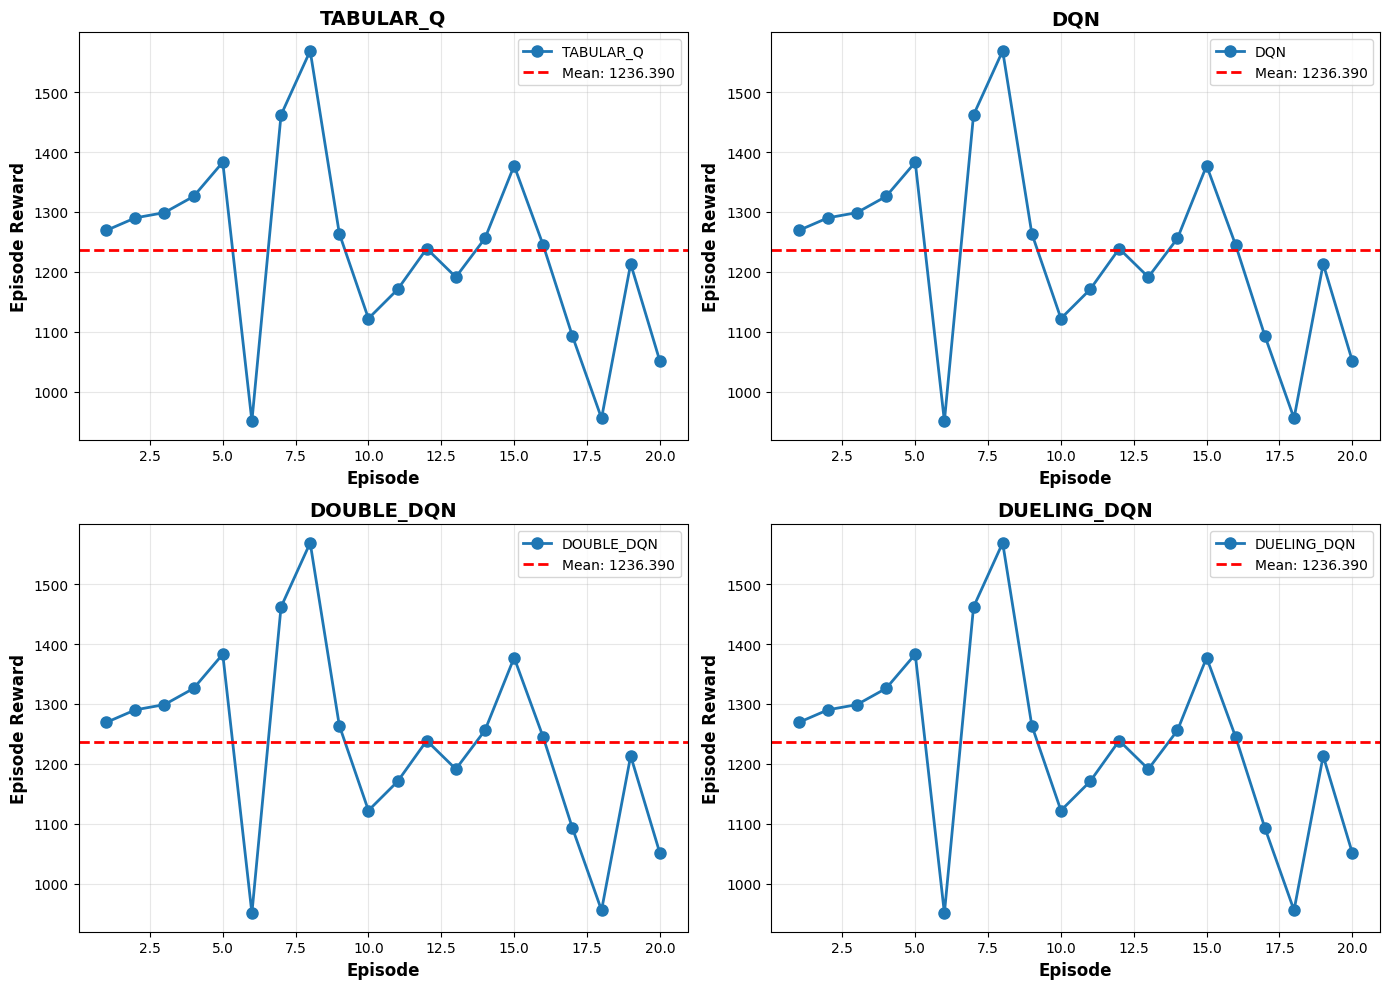

Saved: outputs/agent_comparison/episode_rewards.png


In [25]:
import matplotlib.pyplot as plt

# Create subplots for each agent
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (agent_type, result) in enumerate(benchmark_results.items()):
    ax = axes[idx]
    episode_rewards = result["episode_rewards"]
    episodes = list(range(1, len(episode_rewards) + 1))
    
    ax.plot(episodes, episode_rewards, marker='o', linestyle='-', linewidth=2, markersize=8, label=agent_type.upper())
    ax.axhline(y=np.mean(episode_rewards), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(episode_rewards):.3f}')
    
    ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
    ax.set_ylabel('Episode Reward', fontsize=12, fontweight='bold')
    ax.set_title(f'{agent_type.upper()}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'agent_comparison' / 'episode_rewards.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved: outputs/agent_comparison/episode_rewards.png")

## Section 8: Comparative Analysis

Analyze performance metrics and provide recommendations.

In [26]:
# Find best agents by different metrics
best_by_reward = max(benchmark_results.items(), key=lambda x: x[1]["avg_reward"])
best_by_time = min(benchmark_results.items(), key=lambda x: x[1]["wall_time_seconds"])
best_by_stability = min(benchmark_results.items(), key=lambda x: x[1]["std_reward"])

analysis = {
    "Best by Average Reward": {
        "Agent": best_by_reward[0].upper(),
        "Reward": f"{best_by_reward[1]['avg_reward']:.4f}",
        "Std Dev": f"{best_by_reward[1]['std_reward']:.4f}",
    },
    "Fastest (Wall Clock)": {
        "Agent": best_by_time[0].upper(),
        "Time (s)": f"{best_by_time[1]['wall_time_seconds']:.4f}",
        "Avg Reward": f"{best_by_time[1]['avg_reward']:.4f}",
    },
    "Most Stable (Lowest Variance)": {
        "Agent": best_by_stability[0].upper(),
        "Std Dev": f"{best_by_stability[1]['std_reward']:.4f}",
        "Avg Reward": f"{best_by_stability[1]['avg_reward']:.4f}",
    },
}

display(Markdown("### Performance Winners"))
for category, winner in analysis.items():
    display(Markdown(f"#### {category}"))
    display(JSON(winner))

### Performance Winners

#### Best by Average Reward

<IPython.core.display.JSON object>

#### Fastest (Wall Clock)

<IPython.core.display.JSON object>

#### Most Stable (Lowest Variance)

<IPython.core.display.JSON object>

## Section 9: Recommendations

Guidance for selecting an agent for different scenarios.

In [27]:
recommendations = """
## When to Use Each Agent

### 1. Tabular Q-Learning
- ✓ Use if: State space is small and discretizable
- ✓ Use if: You need maximum interpretability and speed
- ✗ Avoid if: State space is continuous or very large
- **Example**: Simple grid worlds or traffic problems with few discrete lane/phase combinations

### 2. DQN
- ✓ Use if: You need a deep RL baseline for complex state spaces
- ✓ Use if: You want a balance between performance and simplicity
- ✗ Avoid if: You need maximum stability (Q-value overestimation is a known issue)
- **Example**: Real traffic signal control with continuous sensor readings

### 3. Double DQN (Recommended for Production)
- ✓ Use if: You need stable learning with less bias
- ✓ Use if: You're building a production system
- ✓ Use if: You want the best balance of performance and stability
- ✗ Avoid if: You need absolute maximum training speed (slightly slower than DQN)
- **Example**: Real-world traffic signal controllers requiring reliable performance

### 4. Dueling DQN
- ✓ Use if: State value and action advantages are clearly separable
- ✓ Use if: You have complex state spaces with high dimensionality
- ✗ Avoid if: You need maximum simplicity or speed
- ✗ Avoid if: Results show high variance (architectural overhead not beneficial)
- **Example**: Complex traffic networks with rich state information

## Quick Decision Tree

1. **Small discrete state space?** → Tabular Q-Learning
2. **First quick baseline?** → DQN
3. **Production/stable learning?** → Double DQN ⭐
4. **Complex state space?** → Dueling DQN
5. **Unsure?** → Start with Double DQN, benchmark others later
"""

display(Markdown(recommendations))


## When to Use Each Agent

### 1. Tabular Q-Learning
- ✓ Use if: State space is small and discretizable
- ✓ Use if: You need maximum interpretability and speed
- ✗ Avoid if: State space is continuous or very large
- **Example**: Simple grid worlds or traffic problems with few discrete lane/phase combinations

### 2. DQN
- ✓ Use if: You need a deep RL baseline for complex state spaces
- ✓ Use if: You want a balance between performance and simplicity
- ✗ Avoid if: You need maximum stability (Q-value overestimation is a known issue)
- **Example**: Real traffic signal control with continuous sensor readings

### 3. Double DQN (Recommended for Production)
- ✓ Use if: You need stable learning with less bias
- ✓ Use if: You're building a production system
- ✓ Use if: You want the best balance of performance and stability
- ✗ Avoid if: You need absolute maximum training speed (slightly slower than DQN)
- **Example**: Real-world traffic signal controllers requiring reliable performance

### 4. Dueling DQN
- ✓ Use if: State value and action advantages are clearly separable
- ✓ Use if: You have complex state spaces with high dimensionality
- ✗ Avoid if: You need maximum simplicity or speed
- ✗ Avoid if: Results show high variance (architectural overhead not beneficial)
- **Example**: Complex traffic networks with rich state information

## Quick Decision Tree

1. **Small discrete state space?** → Tabular Q-Learning
2. **First quick baseline?** → DQN
3. **Production/stable learning?** → Double DQN ⭐
4. **Complex state space?** → Dueling DQN
5. **Unsure?** → Start with Double DQN, benchmark others later


## Section 10: Save and Export Results

In [28]:
from pathlib import Path

# Ensure output directory exists
output_dir = REPO_ROOT / "outputs" / "agent_comparison"
output_dir.mkdir(parents=True, exist_ok=True)

# Save benchmark results to JSON
results_json_path = output_dir / "benchmark_results.json"
with open(results_json_path, "w") as f:
    json.dump(benchmark_results, f, indent=2)

print(f"✓ Saved benchmark results to: {results_json_path}")

# Save summary statistics
data_source = "PEMS04 Real Traffic Data" if USE_PEMS_DATA else "Synthetic Environment"
summary_stats = {
    "timestamp": pd.Timestamp.now().isoformat(),
    "data_source": data_source,
    "pems_info": {
        "timesteps": int(PEMS_TIMESTEPS),
        "sensors": int(PEMS_NUM_SENSORS),
        "features": int(PEMS_NUM_FEATURES),
    } if USE_PEMS_DATA else None,
    "benchmark_config": BENCHMARK_CONFIG,
    "hyperparameters": SHARED_HYPERPARAMS,
    "best_agents": {
        "by_reward": {"agent": best_by_reward[0], "value": best_by_reward[1]["avg_reward"]},
        "by_speed": {"agent": best_by_time[0], "value": best_by_time[1]["wall_time_seconds"]},
        "by_stability": {"agent": best_by_stability[0], "value": best_by_stability[1]["std_reward"]},
    },
}

summary_json_path = output_dir / "summary_stats.json"
with open(summary_json_path, "w") as f:
    json.dump(summary_stats, f, indent=2)

print(f"✓ Saved summary stats to: {summary_json_path}")
print()
print(f"Output directory: {output_dir}")
print(f"Data source: {data_source}")
print(f"Files:")
for f in sorted(output_dir.glob("*.json")):
    print(f"  - {f.name}")
for f in sorted(output_dir.glob("*.png")):
    print(f"  - {f.name}")

✓ Saved benchmark results to: /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison/benchmark_results.json
✓ Saved summary stats to: /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison/summary_stats.json

Output directory: /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison
Data source: PEMS04 Real Traffic Data
Files:
  - benchmark_results.json
  - summary_stats.json
  - episode_rewards.png
